# Lab 6

Used libraries:

In [3]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping

import scipy as sp

# Task 0 or 1

* Use sample rate 1000 Hz, and take 1000 samples. Sine frequency 10 Hz.

        Amplitude 1.2 V, offset 1.2 V
        Centered at the switching point of digital input.

* Connections:

        AOGND    ⇔ DGND
        AO0      ⇔ PFI0 in


In [7]:
device_name = '/Dev7'

Acquired data: [1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 1.000000, 1.00

Text(0.5, 0, 'sample no')

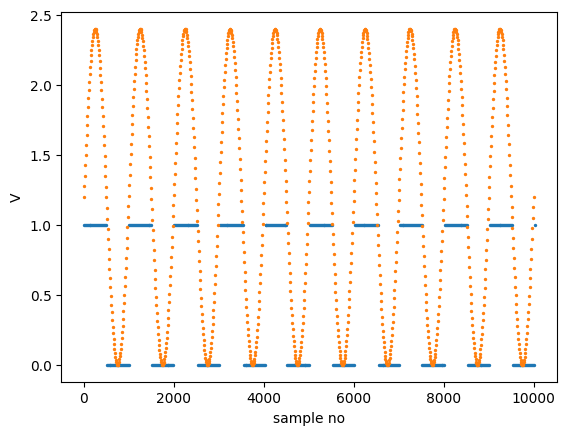

In [6]:
data = []
times = []

sample_time = 10
sample_freq = 100
nsamples = sample_freq*sample_time

start = time.time()

sin_freq    = 1
sin_amp     = 1.2
sin_offset  = 1.2
sin_times = np.linspace(0, sample_time, nsamples)
sin_data = sin_amp * np.sin(2 * np.pi * sin_freq * sin_times) + sin_offset

''' 
'''
with nidaqmx.Task() as di_task, nidaqmx.Task() as ao_task:

    di_task.di_channels.add_di_chan(device_name +"/port0", line_grouping=LineGrouping.CHAN_FOR_ALL_LINES)
    

    ao_task.ao_channels.add_ao_voltage_chan(device_name+"/ao0")
    ao_task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE,
        samps_per_chan=len(sin_data))
    
    ao_task.write(sin_data)

    ao_task.start()
    while not ao_task.is_task_done():
        data += [di_task.read()]
        #time.sleep(1/sample_freq)

    end = time.time()
    times = np.linspace(0, end-start, len(data))

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data) + "]")

plt.scatter(np.linspace(0, times[-1]*1e3, len(data[1:])), data[1:],2)
plt.scatter(sin_times*1e3, sin_data,2)
plt.ylabel('V')
plt.xlabel("sample no")

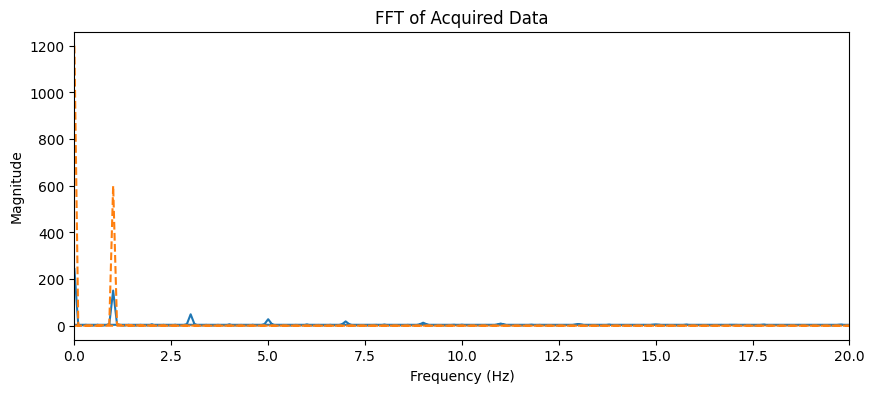

In [15]:
#plot fft and sine wave
fft_data = np.fft.fft(data[1:])
fft_freq = np.fft.fftfreq(len(fft_data), d=sample_time/len(fft_data))

fft_sine = np.fft.fft(sin_data)
fft_sine_freq = np.fft.fftfreq(len(fft_sine), d=sample_time/len(fft_sine))

plt.figure(figsize=(10,4))
plt.plot(fft_freq, np.abs(fft_data))
plt.plot(fft_sine_freq, np.abs(fft_sine), linestyle='dashed')
plt.xlim(0, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Data')
plt.show()

In [21]:

fft_data = np.fft.fft(data[1:])
fft_freq = np.fft.fftfreq(len(fft_data), d=sample_time/len(fft_data))

fft_data = fft_data[fft_freq >= 0]

fft_magnitude = np.abs(fft_data)
fft_magnitude[0] = 0  # Ignore the DC component
peak_index = np.argmax(fft_magnitude)
peak_height = fft_magnitude[peak_index]
# sum of all other peaks is noise
noise_level = np.sum(fft_magnitude) - peak_height
snr = 10 * np.log10(peak_height / noise_level)
print("ratio peak height to noise level:", peak_height / noise_level)
print(f"SNR: {snr:.2f} dB")

ratio peak height to noise level: 0.23043756870623827
SNR: -6.37 dB


# Task 2 Dither

In [11]:
device_name = '/Dev7'

Acquired data: [0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 1.000000, 0.000000, 1.000000, 0.000000, 0.000000, 1.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 1.000000, 1.000000, 1.000000, 0.000000, 1.000000, 0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.00

Text(0.5, 0, 'sample no')

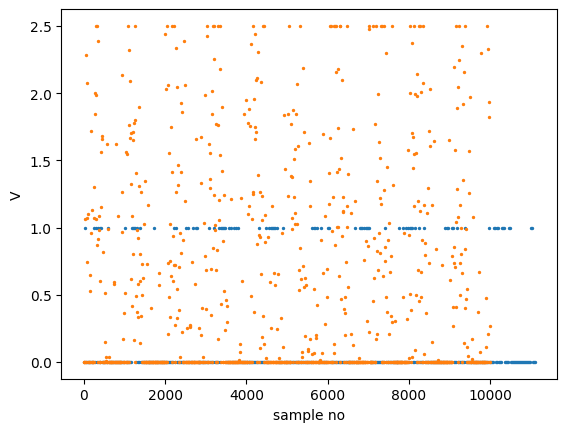

In [7]:
data = []
times = []

sample_time = 10
sample_freq = 100
nsamples = sample_freq*sample_time

start = time.time()

sin_freq    = 1
sin_amp     = 1.2
sin_offset  = 1.2
sin_times = np.linspace(0, sample_time, nsamples)
sin_data = sin_amp * np.sin(2 * np.pi * sin_freq * sin_times) + sin_offset

#gen random noise 
noise = np.random.normal(-1.2, 1.2, len(sin_data))
sin_data += noise

#coercing data to be in range 0-2.5V 
sin_data = np.clip(sin_data, 0, 2.5)

''' 
'''
with nidaqmx.Task() as di_task, nidaqmx.Task() as ao_task:

    di_task.di_channels.add_di_chan(device_name +"/port0", line_grouping=LineGrouping.CHAN_FOR_ALL_LINES)
    

    ao_task.ao_channels.add_ao_voltage_chan(device_name+"/ao0")
    ao_task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE,
        samps_per_chan=len(sin_data))
    
    ao_task.write(sin_data)

    ao_task.start()
    while not ao_task.is_task_done():
        data += [di_task.read()]
        #time.sleep(1/sample_freq)

    end = time.time()
    times = np.linspace(0, end-start, len(data))

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data) + "]")

plt.scatter(np.linspace(0, times[-1]*1e3, len(data[1:])), data[1:],2)
plt.scatter(sin_times*1e3, sin_data,2)
plt.ylabel('V')
plt.xlabel("sample no")

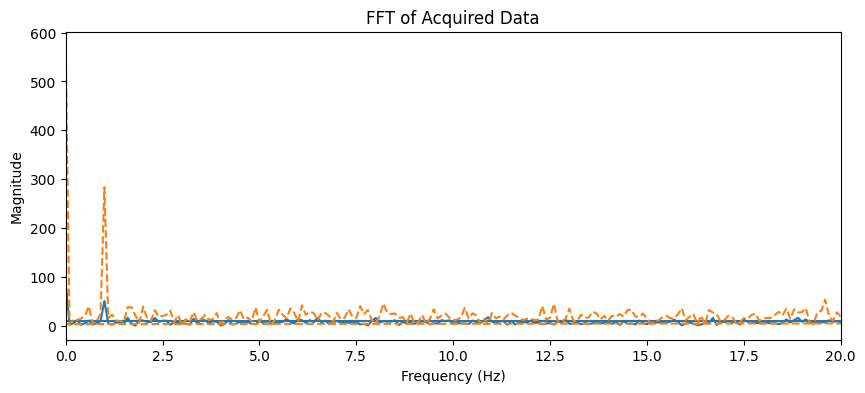

In [8]:
#plot fft and sine wave
fft_data = np.fft.fft(data[1:])
fft_freq = np.fft.fftfreq(len(fft_data), d=sample_time/len(fft_data))

fft_sine = np.fft.fft(sin_data)
fft_sine_freq = np.fft.fftfreq(len(fft_sine), d=sample_time/len(fft_sine))

plt.figure(figsize=(10,4))
plt.plot(fft_freq, np.abs(fft_data))
plt.plot(fft_sine_freq, np.abs(fft_sine), linestyle='dashed')
plt.xlim(0, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Data')
plt.show()

In [9]:

fft_data = np.fft.fft(data[1:])
fft_freq = np.fft.fftfreq(len(fft_data), d=sample_time/len(fft_data))

fft_data = fft_data[fft_freq >= 0]

fft_magnitude = np.abs(fft_data)
fft_magnitude[0] = 0  # Ignore the DC component
peak_index = np.argmax(fft_magnitude)
peak_height = fft_magnitude[peak_index]
# sum of all other peaks is noise
noise_level = np.sum(fft_magnitude) - peak_height
snr = 10 * np.log10(peak_height / noise_level)
print("ratio peak height to noise level:", peak_height / noise_level)
print(f"SNR: {snr:.2f} dB")

ratio peak height to noise level: 0.03112653515200847
SNR: -15.07 dB


Looks kinda trash, but the spectra of the discretised data does seem to bee prettier..

# Task 3

Not sure I understand what is asked.. Should I make a new measurement?

How much are we oversampling > with sin frequency 10 minimum sampling rate is 20, given a rate of 1000 we are oversampling by 50 times

Moving window filter is basically a convolution with a rectangle, which in turn looks like multiplication with fourier transfer of said window in frequency space. Effectively it cuts off higher frequencies. 



# Task 4.1

In [30]:
total_read = 0
sps = 250000                 
duration_s = 1
n_samps = int(sps * duration_s)

n_measures = 1
max_samps = 1_000_000
if n_samps > max_samps:
    n_measures = int(np.ceil(n_samps / max_samps))
    n_samps = int(np.ceil(n_samps / n_measures))

read = np.array([])

with nidaqmx.Task() as aitask, nidaqmx.Task() , nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Arm tasks (important for triggered start)
    for _ in range(n_measures):

        aitask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read_cycle = aitask.read(number_of_samples_per_channel=n_samps)
        read = np.concatenate((read, np.array(read_cycle)))

        aitask.stop()
        trigtask.stop()

total_read = read.size
print(f"Acquired {total_read} samples on ai0.")

Acquired 250000 samples on ai0.


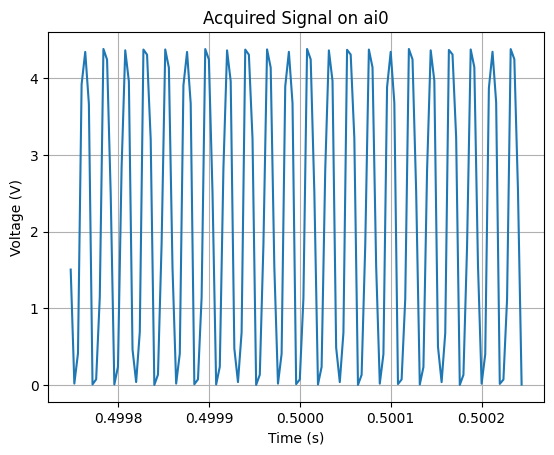

In [31]:
fig, ax = plt.subplots()
cut_time = 0.0005  # s
cut_windowsize = int(cut_time * sps)
cut_start = (total_read - cut_windowsize) // 2
cut_end = cut_start + cut_windowsize
ax.plot(np.arange(total_read)[cut_start:cut_end] / sps, read[cut_start:cut_end])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Acquired Signal on ai0")
ax.grid(True)
plt.show()

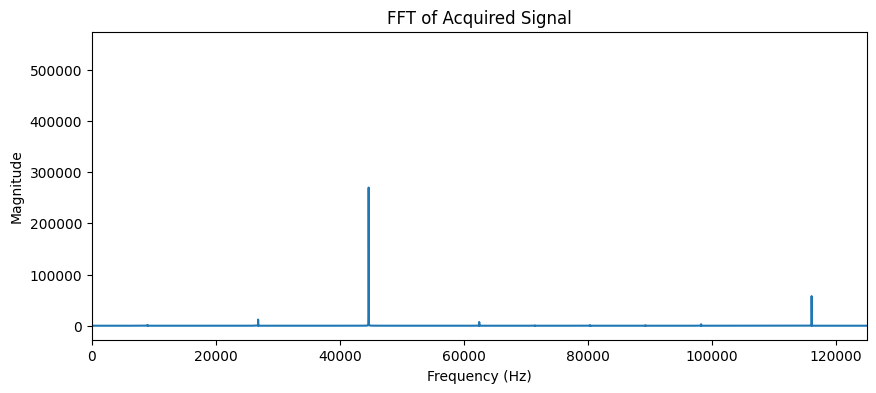

In [32]:
# show fft of acquired signal
fft_data = np.fft.fft(read)
fft_freq = np.fft.fftfreq(len(fft_data), d=1/sps)
fft_data = fft_data[fft_freq >= 0]
fft_freq = fft_freq[fft_freq >= 0]
plt.figure(figsize=(10,4))
plt.plot(fft_freq, np.abs(fft_data))
plt.xlim(0, sps/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Signal')
plt.show()

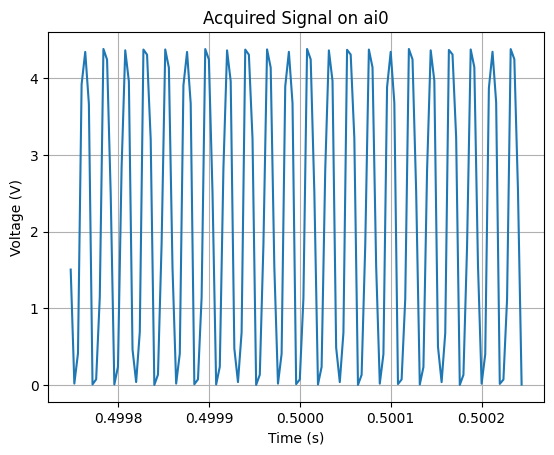

In [33]:
fig, ax = plt.subplots()
cut_time = 0.0005  # s
cut_windowsize = int(cut_time * sps)
cut_start = (total_read - cut_windowsize) // 2
cut_end = cut_start + cut_windowsize
ax.plot(np.arange(total_read)[cut_start:cut_end] / sps, read[cut_start:cut_end])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Acquired Signal on ai0")
ax.grid(True)
plt.show()

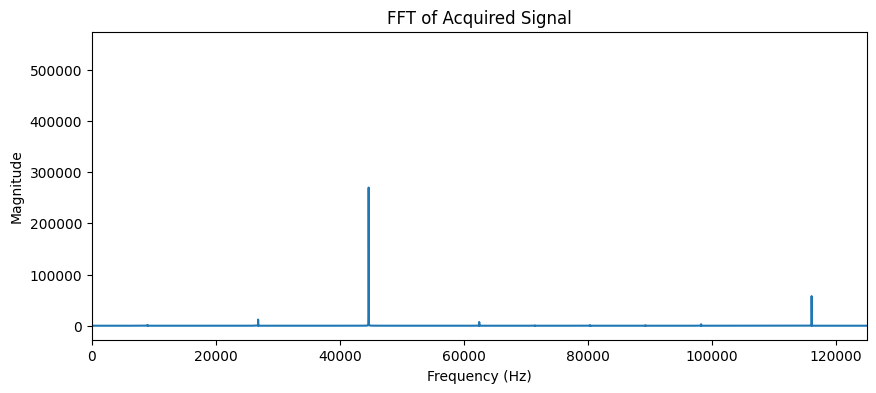

In [34]:
# show fft of acquired signal
fft_data = np.fft.fft(read)
fft_freq = np.fft.fftfreq(len(fft_data), d=1/sps)
fft_data = fft_data[fft_freq >= 0]
fft_freq = fft_freq[fft_freq >= 0]
plt.figure(figsize=(10,4))
plt.plot(fft_freq, np.abs(fft_data))
plt.xlim(0, sps/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Signal')
plt.show()

Looks like there is a peak at 50-ish kHz

In [35]:
total_read = 0
sps = 230000                 
duration_s = 1
n_samps = int(sps * duration_s)

n_measures = 1
max_samps = 1_000_000
if n_samps > max_samps:
    n_measures = int(np.ceil(n_samps / max_samps))
    n_samps = int(np.ceil(n_samps / n_measures))

read = np.array([])

with nidaqmx.Task() as aitask, nidaqmx.Task() , nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Arm tasks (important for triggered start)
    for _ in range(n_measures):

        aitask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read_cycle = aitask.read(number_of_samples_per_channel=n_samps)
        read = np.concatenate((read, np.array(read_cycle)))

        aitask.stop()
        trigtask.stop()

total_read = read.size
print(f"Acquired {total_read} samples on ai0.")

Acquired 230000 samples on ai0.


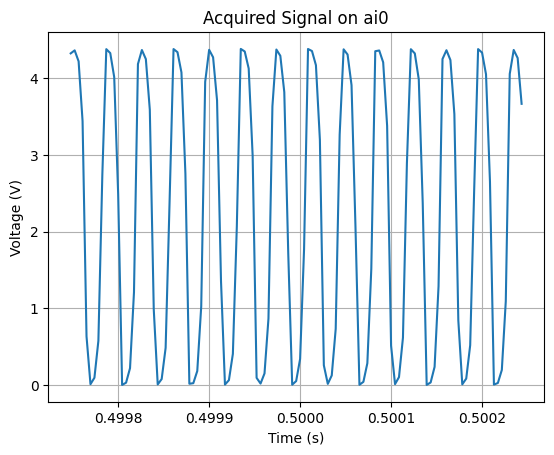

In [38]:
fig, ax = plt.subplots()
cut_time = 0.0005  # s
cut_windowsize = int(cut_time * sps)
cut_start = (total_read - cut_windowsize) // 2
cut_end = cut_start + cut_windowsize
ax.plot(np.arange(total_read)[cut_start:cut_end] / sps, read[cut_start:cut_end])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Acquired Signal on ai0")
ax.grid(True)
plt.show()

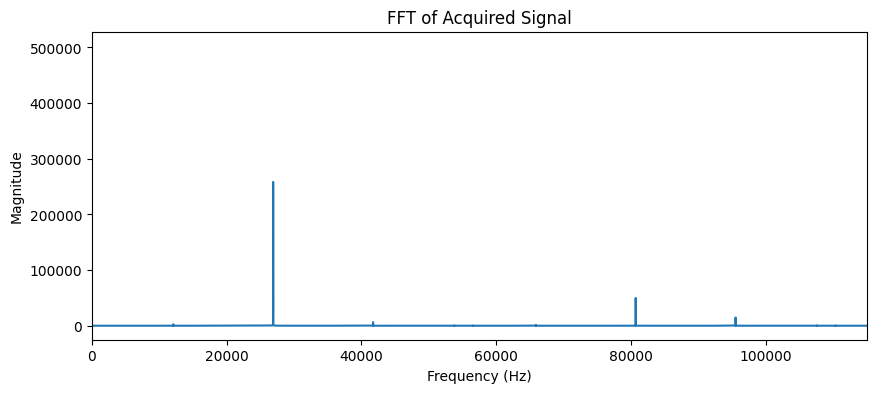

highest peak at frequency: 26896.000000000007


In [39]:
# show fft of acquired signal
fft_data = np.fft.fft(read)
fft_freq = np.fft.fftfreq(len(fft_data), d=1/sps)
fft_data = fft_data[fft_freq >= 0]
fft_freq = fft_freq[fft_freq >= 0]
plt.figure(figsize=(10,4))
plt.plot(fft_freq, np.abs(fft_data))
plt.xlim(0, sps/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Signal')
plt.show()

print("highest peak at frequency:", fft_freq[np.argmax(fft_data[fft_freq > 0])])

Energy seems to be redistributed among other frequencies

Doing the same with D11:

In [40]:
total_read = 0
sps250 = 250000                 
duration_s = 1
n_samps = int(sps250 * duration_s)

n_measures = 1
max_samps = 1_000_000
if n_samps > max_samps:
    n_measures = int(np.ceil(n_samps / max_samps))
    n_samps = int(np.ceil(n_samps / n_measures))

read_D11_250 = np.array([])

with nidaqmx.Task() as aitask, nidaqmx.Task() , nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Arm tasks (important for triggered start)
    for _ in range(n_measures):

        aitask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read_cycle = aitask.read(number_of_samples_per_channel=n_samps)
        read_D11_250 = np.concatenate((read_D11_250, np.array(read_cycle)))

        aitask.stop()
        trigtask.stop()

total_read = read_D11_250.size
print(f"Acquired {total_read} samples on ai0.")

Acquired 250000 samples on ai0.


In [41]:
total_read = 0
sps230 = 230000                 
duration_s = 1
n_samps = int(sps230 * duration_s)

n_measures = 1
max_samps = 1_000_000
if n_samps > max_samps:
    n_measures = int(np.ceil(n_samps / max_samps))
    n_samps = int(np.ceil(n_samps / n_measures))

read_D11_230 = np.array([])

with nidaqmx.Task() as aitask, nidaqmx.Task() , nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Arm tasks (important for triggered start)
    for _ in range(n_measures):

        aitask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read_cycle = aitask.read(number_of_samples_per_channel=n_samps)
        read_D11_230 = np.concatenate((read_D11_230, np.array(read_cycle)))

        aitask.stop()
        trigtask.stop()

total_read = read_D11_230.size
print(f"Acquired {total_read} samples on ai0.")

Acquired 230000 samples on ai0.


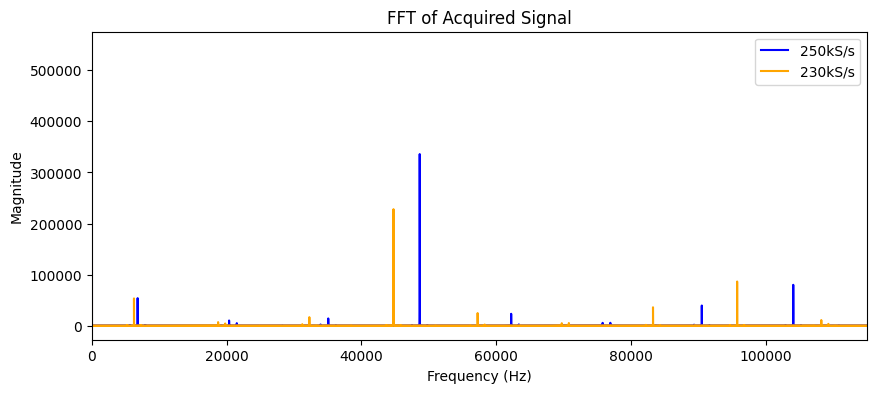

highest peak at frequency: 44750.0


In [42]:
# show fft of acquired signal
plt.figure(figsize=(10,4))
fft_data_250 = np.fft.fft(read_D11_250)
fft_freq_250 = np.fft.fftfreq(len(fft_data_250), d=1/sps250)
plt.plot(fft_freq_250, np.abs(fft_data_250), label='250kS/s', color='blue')
fft_data_230 = np.fft.fft(read_D11_230)
fft_freq_230 = np.fft.fftfreq(len(fft_data_230), d=1/sps230)
plt.plot(fft_freq_230, np.abs(fft_data_230), label='230kS/s', color='orange')
plt.xlim(0, sps230/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Signal')
plt.legend()
plt.show()

print("highest peak at frequency:", fft_freq_250[np.argmax(fft_data_230[fft_freq_230 > 0])])

Looks like there are multiple frequency components. There is also some kind of shift in frequencies, probably due to alasing. The frequency looks to be a miltiple of 50kHz

# Task 4.2

In [6]:
device_name = '/Dev7'

Acquired 250000 samples on ai0.
highest peak at frequency:  45248.0000peak height in dB: 55.23


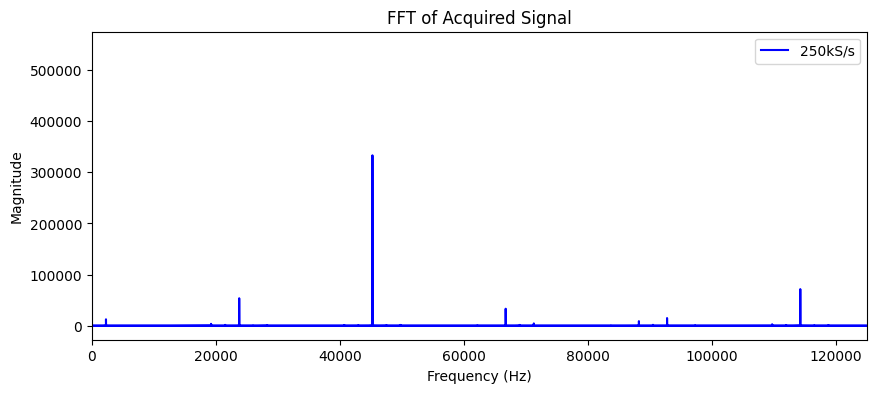

In [27]:
total_read = 0
sps = 250000                 
duration_s = 1
n_samps = int(sps * duration_s)

n_measures = 1
max_samps = 1_000_000
if n_samps > max_samps:
    n_measures = int(np.ceil(n_samps / max_samps))
    n_samps = int(np.ceil(n_samps / n_measures))

read_alias = np.array([])

with nidaqmx.Task() as aitask, nidaqmx.Task() , nidaqmx.Task() as trigtask:
    # AI: single channel (ai0), finite, same length as AO
    aitask.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5, max_val=5
    )
    aitask.timing.cfg_samp_clk_timing(
        sps,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=n_samps
    )
    aitask.triggers.start_trigger.cfg_dig_edge_start_trig(device_name + "/PFI4")

    # Single digital line to issue the trigger
    trigtask.do_channels.add_do_chan(f"{device_name}/port1/line0")

    # Arm tasks (important for triggered start)
    for _ in range(n_measures):

        aitask.start()
        trigtask.start()

        # One trigger pulse → one cycle
        trigtask.write(False)
        trigtask.write(True)

        # Single blocking read of the whole record
        read_cycle = aitask.read(number_of_samples_per_channel=n_samps)
        read_alias = np.concatenate((read_alias, np.array(read_cycle)))

        aitask.stop()
        trigtask.stop()

total_read = read_alias.size
print(f"Acquired {total_read} samples on ai0.")


# show fft of acquired alias signal
plt.figure(figsize=(10,4))
fft_alias_data = np.fft.fft(read_alias)
fft_alias_freq = np.fft.fftfreq(len(fft_alias_data), d=1/sps)
plt.plot(fft_alias_freq, np.abs(fft_alias_data), label='250kS/s', color='blue')
plt.xlim(0, sps/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Acquired Signal')
plt.legend()
print(f"highest peak at frequency: {fft_alias_freq[np.argmax(fft_alias_data[fft_alias_freq > 0])]: .4f}peak height in dB: {10*np.log10(np.max(np.abs(fft_alias_data[fft_alias_freq > 0]))):.4g}")
plt.show()



In [21]:
#rc low pass filter  calculation
R = 120  # resistance in ohms
C = 10e-9  # capacitance in farads
fc = 1e-3* 1 / (2 * np.pi * R * C)  # cutoff frequency
print(f"f: {fc:.4g} kHz")

f: 132.6 kHz


In [28]:
54.49 - 52.76

1.730000000000004

| Arduino PIN | Detected frequency | Signal power at detected frequency | Possible frequencies | Low Pass Filter cutoff | LPF resistor, $\mathrm{C}=10 \mathrm{nF}$ | Measured power at detected frequency after filtering | In passband / stopband | True frequency |
|-------------|--------------------|------------------------------------|----------------------|------------------------|-------------------------------------------|------------------------------------------------------|------------------------|----------------|
|             | [kHz]              | [dB]                               | [kHz]                | [kHz]                  | [Ohm]                                     | [dB]                                                 | [PB/SB]                | [kHz]          |
| D6          | 44.6               | 53.84                              | 44.6                 | 72.34                  | 220                                       | 49.32                                                | 53.84 - 49.32 = 4.52   | 85.2           |
|             |                    |                                    |                      | inf                    | 0                                         |                                                      |                        |                |
|             |                    |                                    |                      |                        |                                           |                                                      |                        |                |
|             |                    |                                    |                      |                        |                                           |                                                      |                        |                |
| D9          | 83.7               | 53.47                              | 83.7                 | 72.34                  | 220                                       | 46.42                                                |                        |                |
|             | 83.7               | 53.47                              |                      | inf                    | 0                                         |                                                      |                        |                |
|             |                    |                                    |                      | 132.6                  | 120                                       | 48.95                                                | 5.54                   | 167.4          |
|             |                    |                                    |                      |                        |                                           |                                                      |                        |                |
| D11         | 45.2               | 54.49                              | 45.2                 | 72.34                  | 220                                       | 52.76                                                | 1.73                   | 45.2           |
|             | 45.2               | 54.49                              | 45.2                 | inf                    | 0                                         |                                                      |                        |                |
|             |                    |                                    |                      |                        |                                           |                                                      |                        |                |
|             |                    |                                    |                      |                        |                                           |                                                      |                        |                |

I'm not at all sure I did it right... I measeured the D6 frequency to be smaller by ca 4.5dB. This means that whatever the master frequency is, the filter slashes it by 4.5db. At the filter cutoff the "slashing" is 3db, so 72hz is less than the master frequency, but not by much. Using this logic, the probable frequency is around twice the measured one.. If I understood the principle correctly. Similar logic goes with other frequencies although I am very hesitant to the exactness of this methodology as the calculation should by all rights involve the sampling frequency as well as the detected one.. I guess I need some more thinking on the topic.

# Tasks

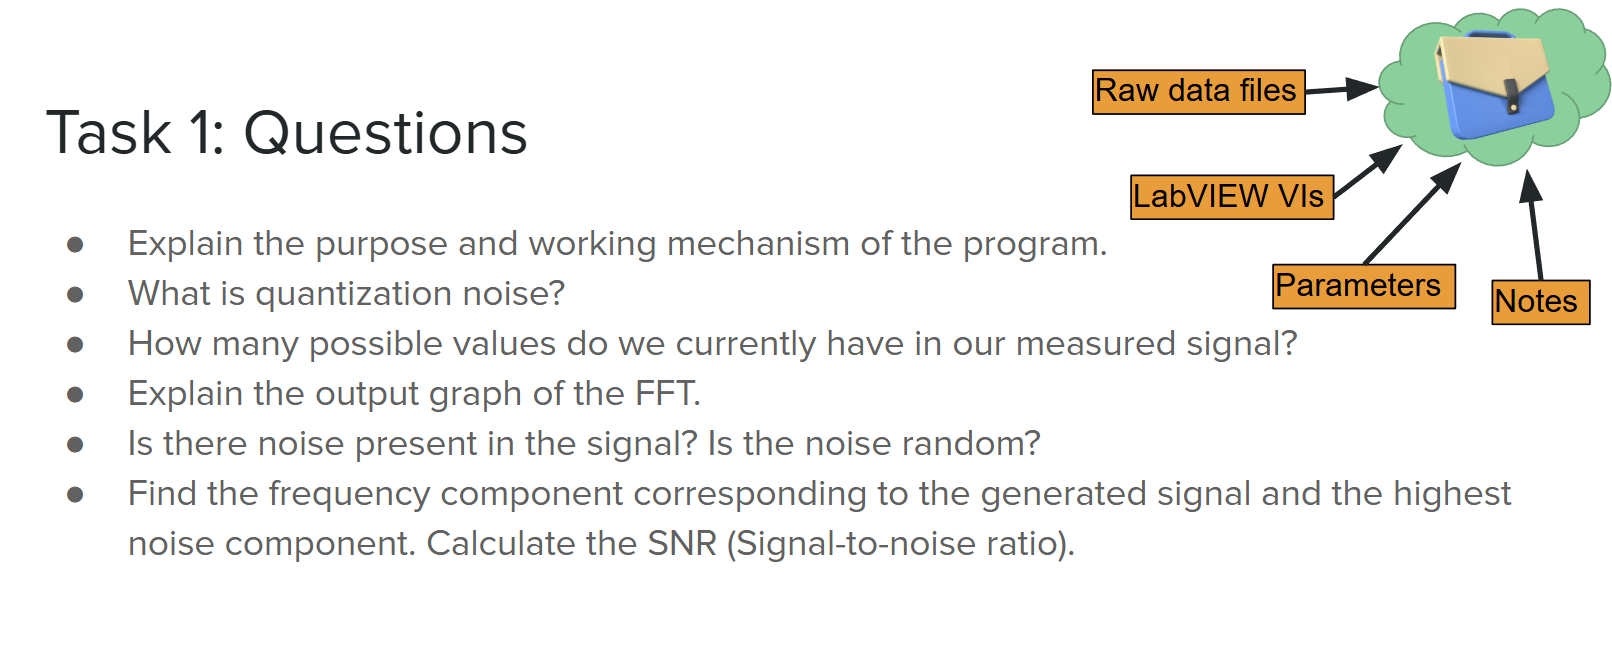

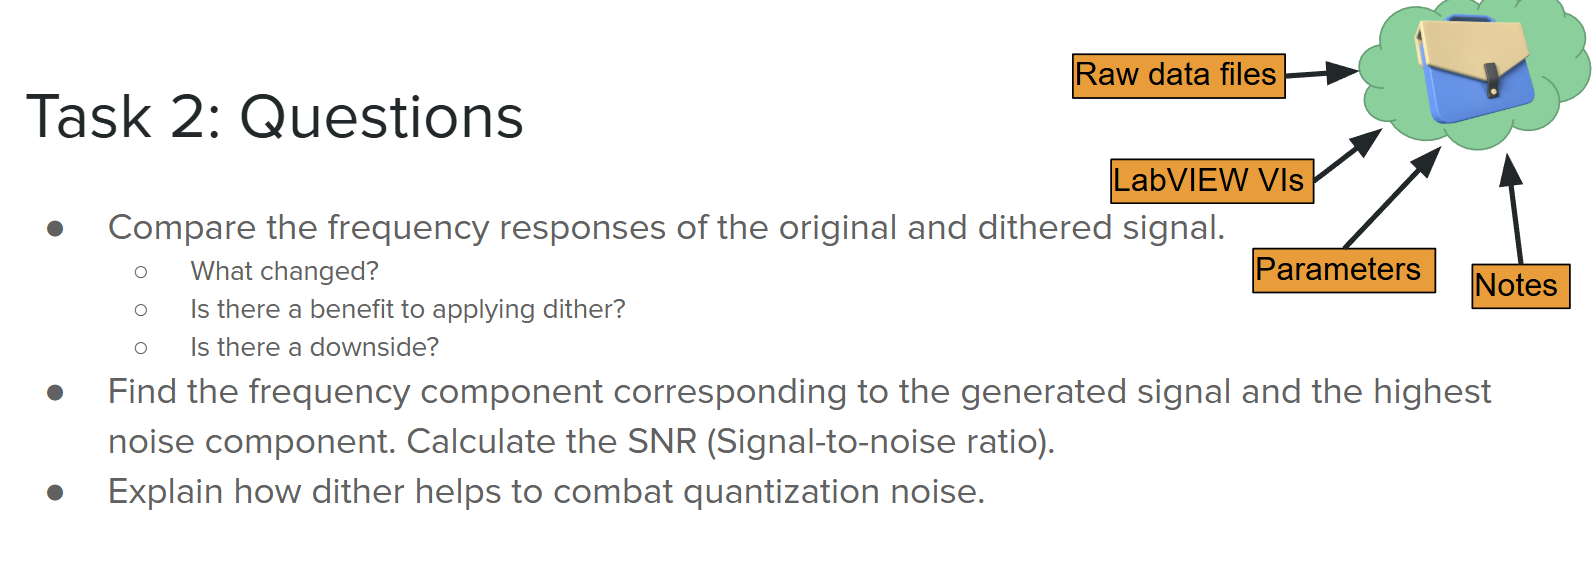

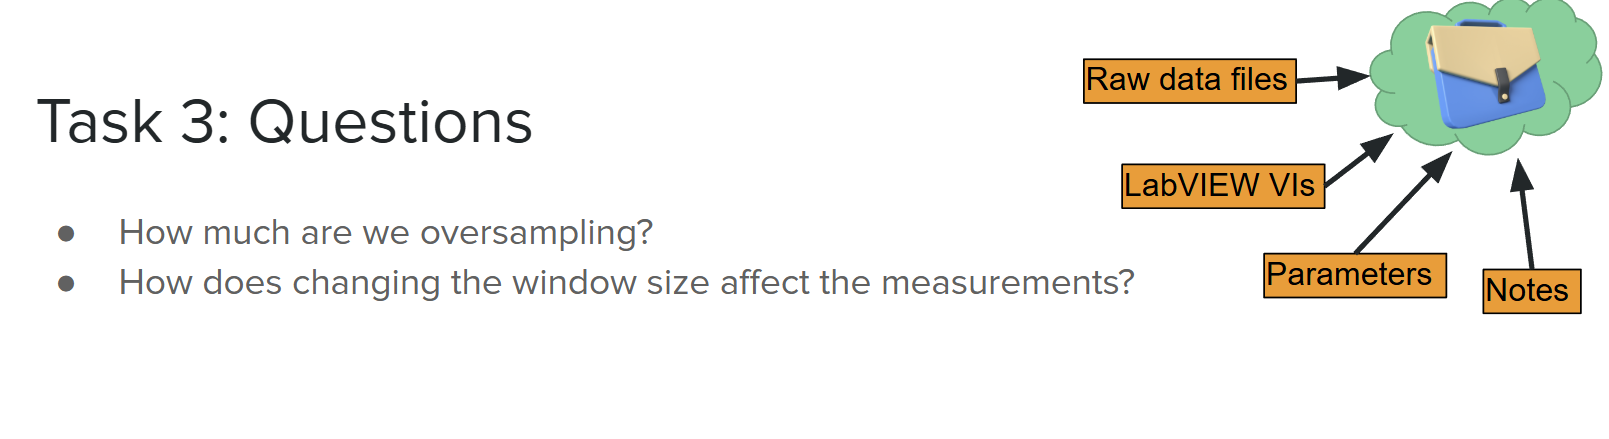

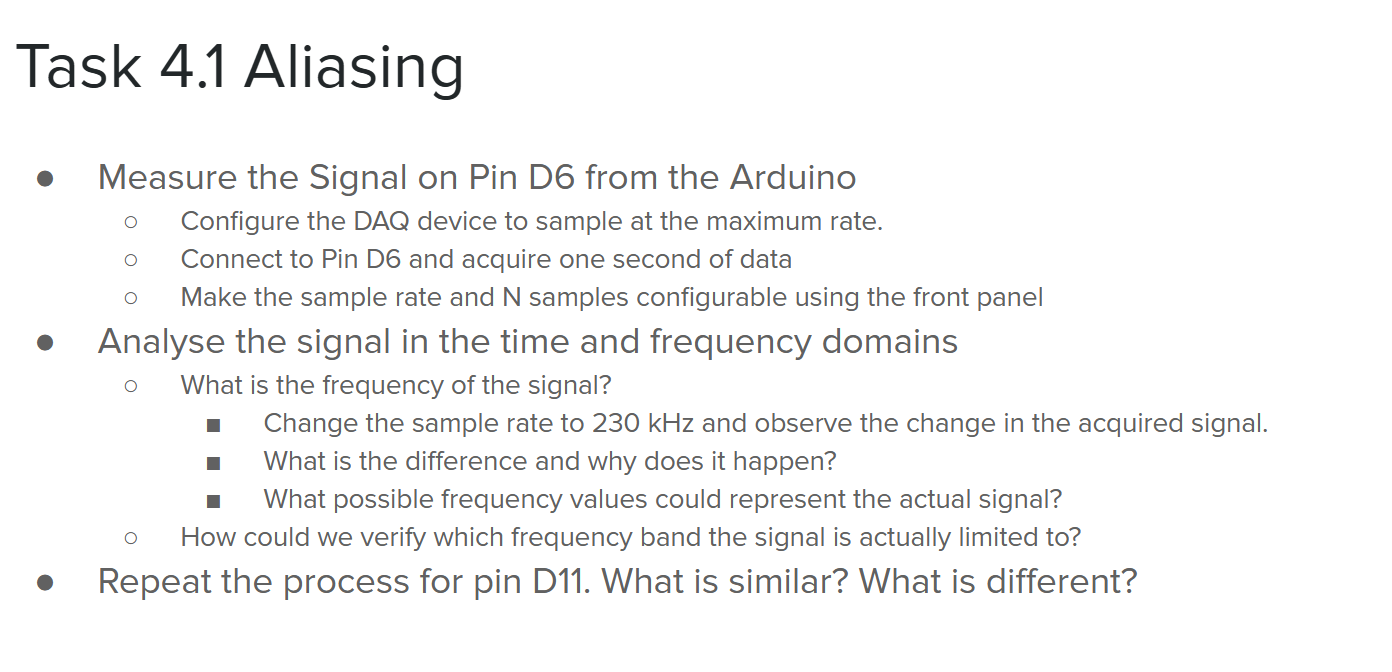

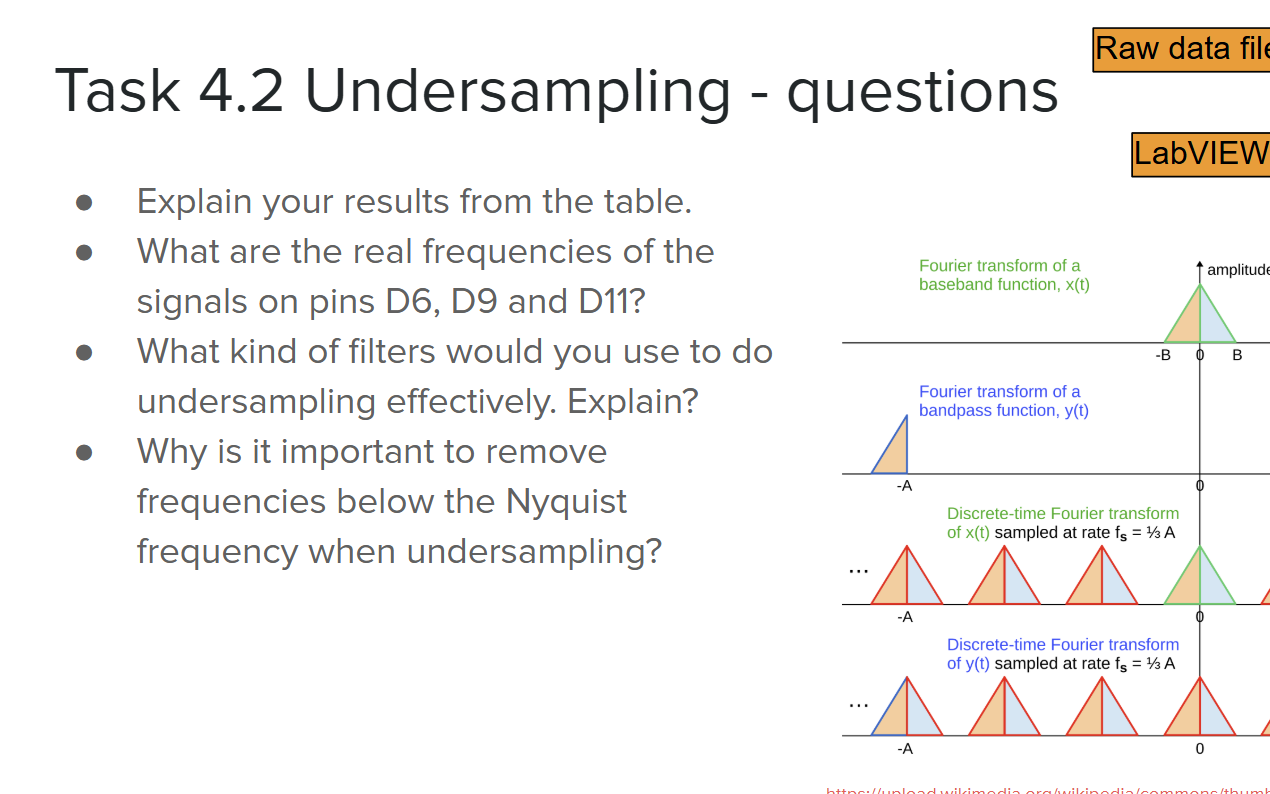